# Predicción de la eficiencia del combustible utilizando XGBoost Regressor

## Aplicando la metodología CRISP-DM

Curso: Minería de Datos

Algoritmo:
XGBoost Regressor

Dataset:
Auto MPG Dataset

Integrante: José Eduardo De La Cuba Zambrano

## 1. Entendimiento del Negocio

### 1.1 Antecedentes

El consumo de combustible es uno de los factores más importantes en la industria automotriz. El dataset Auto MPG contiene información técnica de vehículos fabricados durante los años 70 y 80, permitiendo analizar qué características influyen en la eficiencia del combustible.

### 1.2 Problema de negocio

Desarrollar un modelo capaz de predecir el rendimiento de combustible (MPG) de un automóvil utilizando sus características técnicas.

### 1.3 Objetivo General

Desarrollar un modelo de Regresión Logística que permita predecir el rendimiento de combustible de un automóvil.

### 1.4 Objetivos específicos

-Comprender los datos.

-Preparar los datos.

-Entrenar un modelo.

-Evaluar el desempeño.

### 1.5 Criterios de éxito

• Obtener un valor bajo de MAE.

• Obtener un valor bajo de RMSE.

• Obtener un coeficiente R² cercano a 1.

• Obtener predicciones cercanas a los valores reales.

## 2. Entendimiento de los Datos

### 2.1 Importación de librerías

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### 2.2 Lectura inicial de los datos

El conjunto de datos se encuentra almacenado en un archivo de texto (`auto-mpg.data`). Debido a que las columnas están separadas por espacios y no existe una fila de encabezados, se asignan manualmente los nombres de las variables siguiendo la documentación oficial del dataset.

Además, los valores representados por el símbolo `?` corresponden a datos faltantes y son convertidos automáticamente en valores nulos (`NaN`) para facilitar su tratamiento en etapas posteriores.

In [65]:
columnas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    "auto-mpg.data",
    sep=r"\s+",
    names=columnas,
    na_values="?"
)

Se muestran los primeros registros del conjunto de datos para conocer su estructura.

In [66]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


Se verifica la cantidad de registros y variables presentes en el conjunto de datos.

In [67]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 398
Columnas: 9


Se identifican los tipos de datos de cada variable y la cantidad de valores no nulos.

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


Ultimos registros

In [69]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


### 2.3 Información general del conjunto de datos

Se analiza la estructura general del dataset para conocer el número de registros, la cantidad de variables y el tipo de dato de cada una.

In [70]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 398
Número de variables: 9


In [71]:
#Tipo de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [72]:
#Memoria Utilizada
df.memory_usage(deep=True)

Index             132
mpg              3184
cylinders        3184
displacement     3184
horsepower       3184
weight           3184
acceleration     3184
model_year       3184
origin           3184
car_name        25908
dtype: int64

### 2.4 Descripción de las variables

La siguiente tabla describe las variables presentes en el conjunto de datos.

| Variable     | Tipo       | Descripción                                                    |
| ------------ | ---------- | -------------------------------------------------------------- |
| mpg          | Continua   | Millas recorridas por galón de combustible (Variable objetivo) |
| cylinders    | Entera     | Número de cilindros del motor                                  |
| displacement | Continua   | Cilindrada del motor                                           |
| horsepower   | Continua   | Potencia del motor (HP)                                        |
| weight       | Continua   | Peso del vehículo                                              |
| acceleration | Continua   | Tiempo de aceleración                                          |
| model_year   | Entera     | Año del modelo                                                 |
| origin       | Entera     | País de origen                                                 |
| car_name     | Categórica | Nombre del vehículo                                            |


### 2.5 Estadística descriptiva

Se obtienen medidas estadísticas que permiten resumir el comportamiento de las variables numéricas.

In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


### 2.6 Calidad de los datos

Se verifica la existencia de valores faltantes y registros duplicados que puedan afectar el desempeño del modelo.

In [74]:
#Valores faltantes
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [75]:
#Registros duplicados
df.duplicated().sum()

np.int64(0)

### 2.7 Distribución de las variables

Se analiza la distribución de las variables numéricas mediante histogramas para comprender su comportamiento.

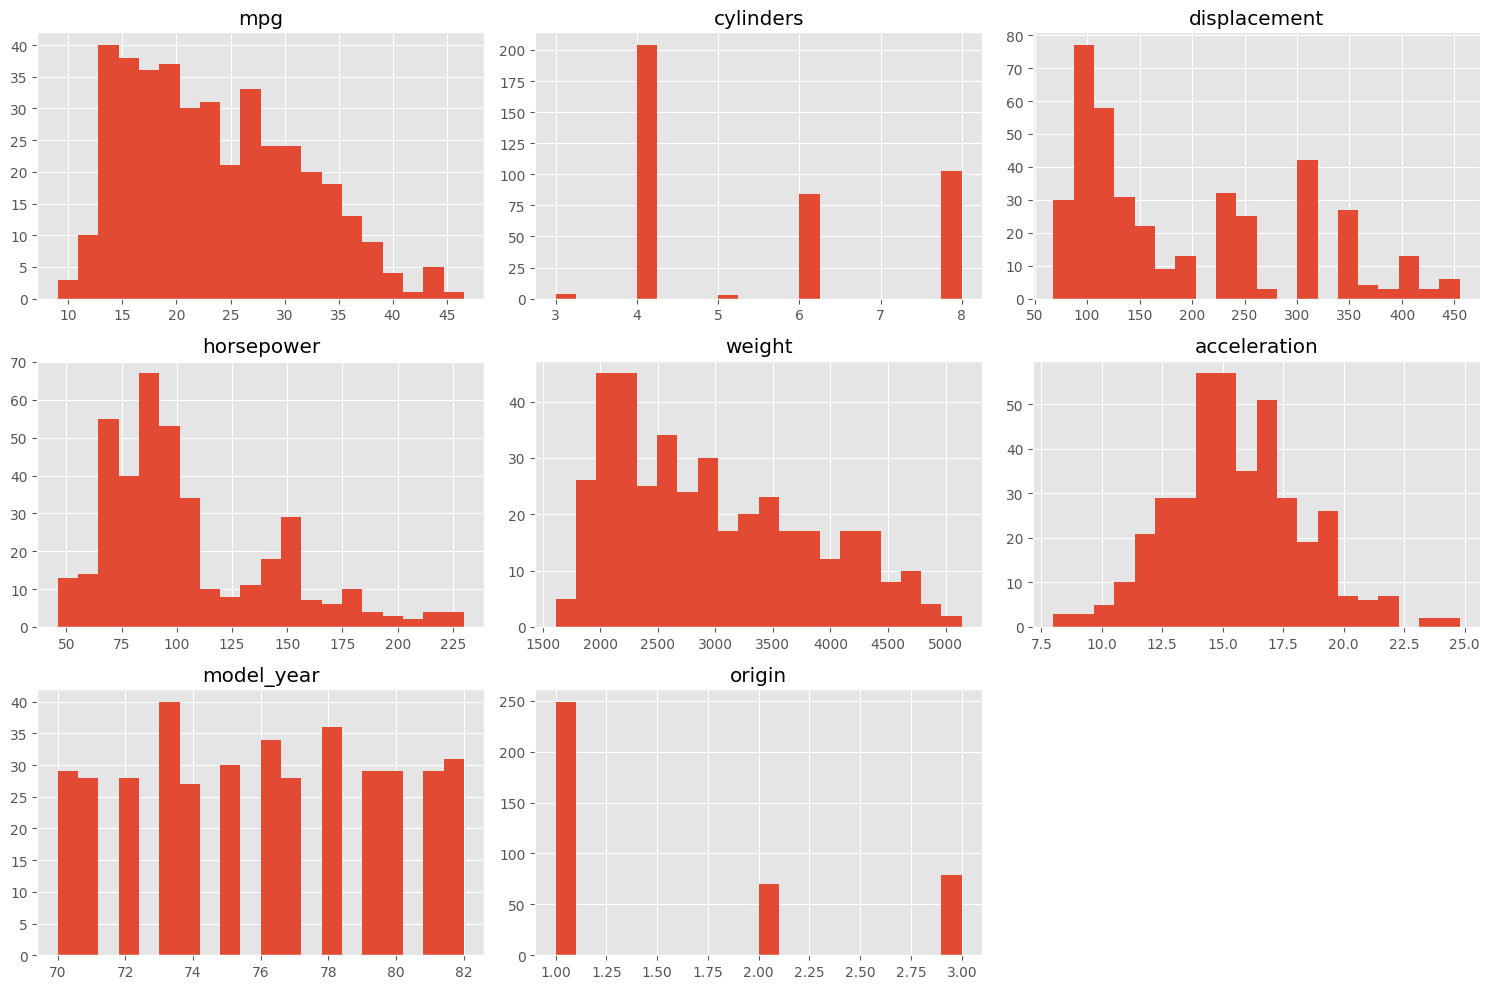

In [76]:
df.hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

### 2.8 Distribución de la variable objetivo (mpg)

La variable objetivo del problema es **mpg**, la cual representa las millas recorridas por galón de combustible.

Se analiza su distribución para conocer el rango de valores presentes y detectar posibles concentraciones o asimetrías.

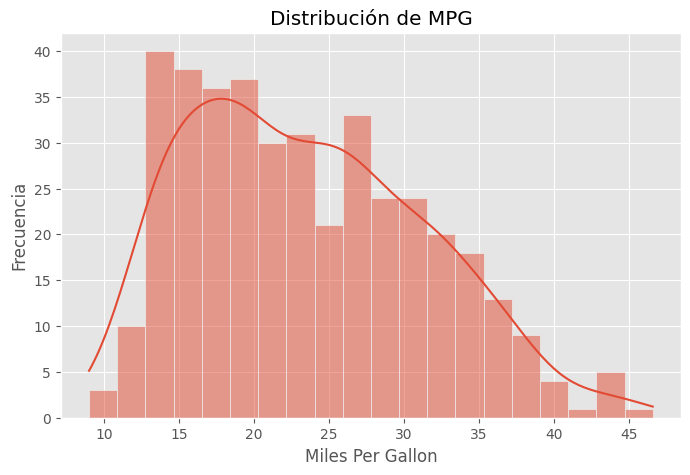

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df["mpg"], bins=20, kde=True)

plt.title("Distribución de MPG")

plt.xlabel("Miles Per Gallon")

plt.ylabel("Frecuencia")

plt.show()

### 2.9 Distribución de la variable "origin"

Se analiza la cantidad de vehículos según su país de origen.

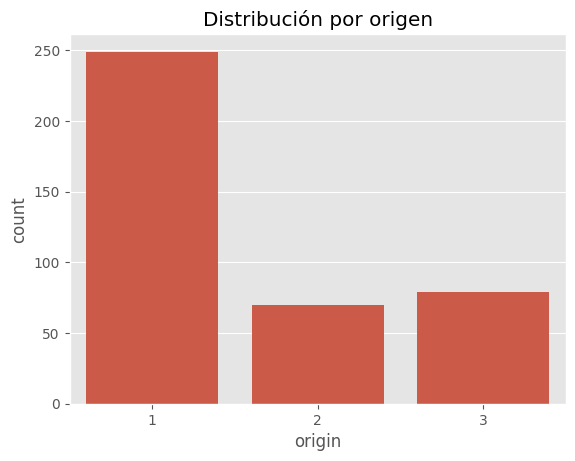

In [78]:
sns.countplot(x="origin", data=df)

plt.title("Distribución por origen")

plt.show()

### 2.10 Detección de valores atípicos

Se utilizan diagramas de caja para identificar posibles observaciones extremas en las variables numéricas.

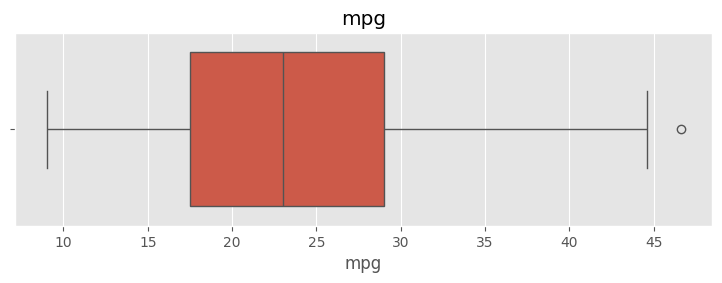

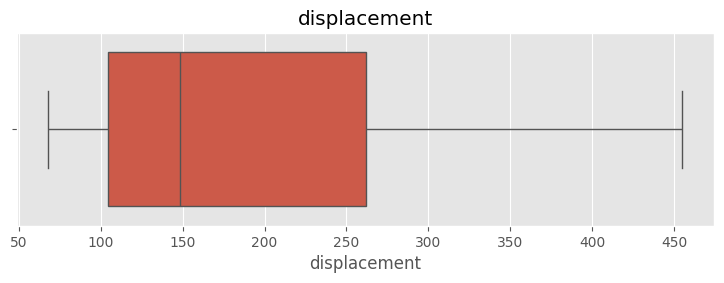

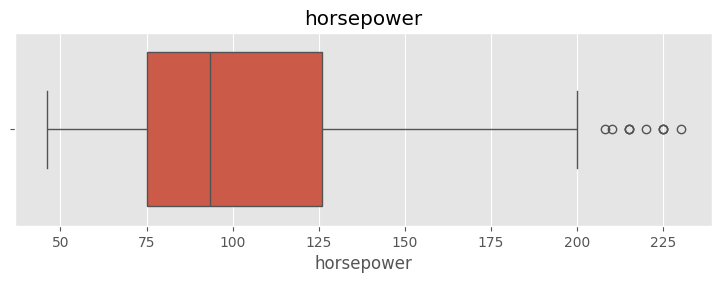

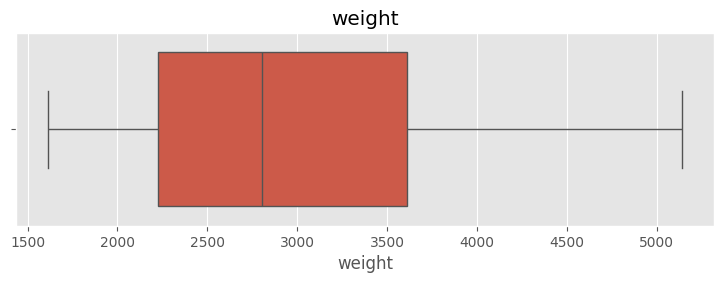

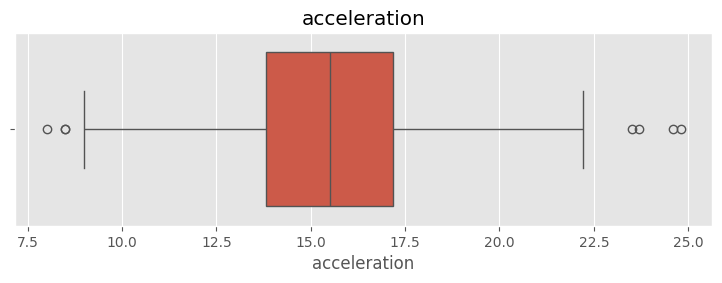

In [79]:
variables = [
    "mpg",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]

for variable in variables:

    plt.figure(figsize=(9,2.5))

    sns.boxplot(x=df[variable])

    plt.title(variable)

    plt.show()

### 2.11 Correlación entre variables

Se analiza la relación lineal existente entre las variables numéricas mediante una matriz de correlación.

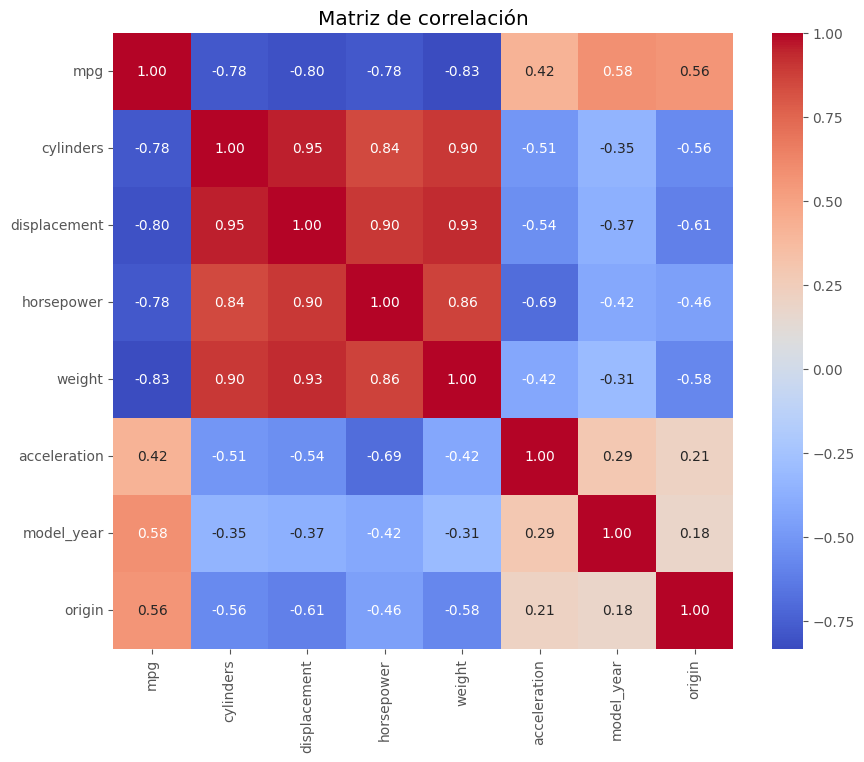

In [80]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

### 2.12 Conclusiones del Entendimiento de los Datos

A partir del análisis exploratorio realizado se identificaron los siguientes aspectos relevantes:

- El conjunto de datos está conformado por **398 registros** y **9 variables**, de las cuales **mpg** es la variable objetivo utilizada para el problema de regresión.
- La variable **horsepower** presenta valores faltantes, por lo que será necesario aplicar una estrategia de imputación durante la fase de Preparación de los Datos.
- No se identificaron problemas importantes en la estructura general del conjunto de datos; sin embargo, es conveniente verificar la existencia de registros duplicados y posibles valores atípicos antes del entrenamiento del modelo.
- Variables como **weight**, **horsepower** y **displacement** muestran una relación significativa con la eficiencia del combustible, lo que sugiere que tendrán un papel importante en la construcción del modelo predictivo.
- La información obtenida en esta fase servirá como base para realizar las tareas de limpieza, transformación y selección de variables durante la siguiente etapa de la metodología CRISP-DM.

## 3. Preparación de los Datos

En esta fase de la metodología CRISP-DM se realizan todas las actividades necesarias para transformar el conjunto de datos en una versión adecuada para el entrenamiento del modelo de aprendizaje automático.

Las tareas desarrolladas incluyen la selección de variables, el tratamiento de valores faltantes, la eliminación de atributos innecesarios, la codificación de variables categóricas y la división del conjunto de datos en entrenamiento y prueba.

### 3.1 Selección de los datos

Se identifican las variables que serán utilizadas durante el proceso de modelado.

La variable objetivo corresponde a **mpg**, mientras que las demás variables representan las características técnicas de cada vehículo.

In [81]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### 3.2 Limpieza de datos

Antes de entrenar el modelo es necesario verificar nuevamente la existencia de valores faltantes y preparar el conjunto de datos para su procesamiento.

In [82]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

### 3.3 Tratamiento de valores faltantes

La variable **horsepower** presenta algunos valores faltantes. Debido a que se trata de una variable numérica continua y la cantidad de datos ausentes es reducida, se reemplazan utilizando la mediana, ya que esta medida es menos sensible a valores atípicos.

In [83]:
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

In [84]:
#Verificamos nuevamente
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

### 3.4 Eliminación de variables innecesarias

La variable **car_name** contiene únicamente el nombre del vehículo y no aporta información numérica relevante para el modelo de regresión. Por esta razón se elimina del conjunto de datos.

In [85]:
df = df.drop(columns=["car_name"])

La variable car_name corresponde únicamente al nombre comercial del vehículo y no aporta información numérica relevante para el modelo predictivo, por lo que se elimina del conjunto de datos.

In [86]:
#Verificamos Nuevamente
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### 3.5 Conversión de tipos de datos

Se verifica que todas las variables numéricas tengan el tipo de dato adecuado para evitar problemas durante el entrenamiento del modelo.

In [87]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

### 3.6 Codificación de variables categóricas

La variable **origin** representa el país de origen del vehículo mediante códigos numéricos (1 = Estados Unidos, 2 = Europa y 3 = Japón).

Aunque XGBoost puede trabajar con variables numéricas, se opta por aplicar codificación One-Hot Encoding para evitar que el modelo interprete estos códigos como una relación ordinal.

In [88]:
df = pd.get_dummies(
    df,
    columns=["origin"],
    drop_first=True,
    dtype=int
)

#Visualizamos nuevamente
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0


### 3.7 Selección de variables predictoras y variable objetivo

Se separa la variable objetivo (**mpg**) de las variables predictoras que serán utilizadas durante el entrenamiento del modelo.

In [89]:
X = df.drop(columns=["mpg"])

y = df["mpg"]

#Verificamos

print(X.shape)
print(y.shape)

(398, 8)
(398,)


### 3.8 División del conjunto de datos

El conjunto de datos se divide en datos de entrenamiento y prueba.

Se utiliza un 80% de los registros para entrenar el modelo y el 20% restante para evaluar su capacidad de predicción sobre datos no vistos.

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#Verificamos


print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (318, 8)
Prueba: (80, 8)


### 3.9 Verificación final de los datos

Finalmente se verifica que el conjunto de datos se encuentre correctamente preparado antes de iniciar la fase de modelado.

In [91]:
print(X_train.info())


<class 'pandas.DataFrame'>
Index: 318 entries, 3 to 102
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     318 non-null    int64  
 1   displacement  318 non-null    float64
 2   horsepower    318 non-null    float64
 3   weight        318 non-null    float64
 4   acceleration  318 non-null    float64
 5   model_year    318 non-null    int64  
 6   origin_2      318 non-null    int64  
 7   origin_3      318 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 22.4 KB
None


In [92]:
print(X_test.info())

<class 'pandas.DataFrame'>
Index: 80 entries, 198 to 285
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     80 non-null     int64  
 1   displacement  80 non-null     float64
 2   horsepower    80 non-null     float64
 3   weight        80 non-null     float64
 4   acceleration  80 non-null     float64
 5   model_year    80 non-null     int64  
 6   origin_2      80 non-null     int64  
 7   origin_3      80 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 5.6 KB
None


In [93]:
X_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
3,8,304.0,150.0,3433.0,12.0,70,0,0
18,4,97.0,88.0,2130.0,14.5,70,0,1
376,4,91.0,68.0,2025.0,18.2,82,0,1
248,4,91.0,60.0,1800.0,16.4,78,0,1
177,4,115.0,95.0,2694.0,15.0,75,1,0


### 3.10 Conclusiones de la Preparación de los Datos

Durante esta fase se realizaron las actividades necesarias para preparar el conjunto de datos antes del entrenamiento del modelo.

Las principales acciones desarrolladas fueron:

- Se trataron los valores faltantes presentes en la variable **horsepower** mediante imputación con la mediana.
- Se eliminó la variable **car_name**, ya que funciona únicamente como identificador y no aporta información útil para la predicción.
- Se aplicó codificación **One-Hot Encoding** a la variable **origin**, permitiendo representar correctamente el país de origen de cada vehículo.
- Se separaron las variables predictoras de la variable objetivo (**mpg**).
- Se dividió el conjunto de datos en entrenamiento (80%) y prueba (20%), garantizando una evaluación objetiva del modelo.

Con estas transformaciones, los datos quedaron preparados para la construcción del modelo de regresión mediante **XGBRegressor**.

## 4. Modelado

En esta fase de la metodología CRISP-DM se construye el modelo de aprendizaje automático utilizando el algoritmo **XGBoost Regressor**.

Este algoritmo está basado en árboles de decisión potenciados mediante **Gradient Boosting**, técnica que consiste en entrenar múltiples árboles secuencialmente, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

XGBoost es ampliamente utilizado en problemas de regresión debido a su alta precisión, rapidez de entrenamiento y capacidad para modelar relaciones complejas entre las variables.

### 4.1 Importación del algoritmo

Se importa la implementación de **XGBRegressor** desde la librería XGBoost junto con las métricas necesarias para evaluar el modelo.

In [94]:
# Importación del modelo XGBoost para problemas de regresión
from xgboost import XGBRegressor

# Importación de métricas para evaluar el modelo
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Librería para calcular la raíz cuadrada del MSE
import numpy as np

### 4.2 Construcción del modelo

Se crea una instancia del algoritmo **XGBRegressor**.

Para este proyecto inicialmente se utilizarán los parámetros por defecto, modificando únicamente la función objetivo y la semilla aleatoria para garantizar la reproducibilidad de los resultados.

In [95]:
# Creación del modelo XGBoost para regresión
modelo = XGBRegressor(

    # Función objetivo para problemas de regresión
    objective="reg:squarederror",

    # Semilla para obtener siempre los mismos resultados
    random_state=42
)

### 4.3 Entrenamiento del modelo

El modelo aprende la relación existente entre las variables predictoras y la variable objetivo utilizando únicamente los datos de entrenamiento.

In [96]:
# Entrenamiento del modelo utilizando los datos de entrenamiento
modelo.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [97]:
# =======================================
# Información del modelo entrenado
# =======================================

print(modelo)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


### 4.4 Predicción

Una vez entrenado el modelo, se realizan predicciones utilizando los datos de prueba.

Estas predicciones serán comparadas posteriormente con los valores reales para evaluar el desempeño del modelo.

In [98]:
# Predicción de los valores de MPG
y_pred = modelo.predict(X_test)

### 4.5 Comparación entre valores reales y predichos

Se construye una tabla comparativa para observar la diferencia entre los valores reales y las predicciones realizadas por el modelo.

In [99]:
# Crear un DataFrame con los resultados
comparacion = pd.DataFrame({

    "Valor Real": y_test,

    "Valor Predicho": y_pred

})

# Mostrar los primeros registros
comparacion.head(10)

,Valor Real,Valor Predicho
198,33.0,31.683475
396,28.0,29.145233
33,19.0,20.787872
208,13.0,15.331271
93,14.0,14.008014
84,27.0,25.813898
373,24.0,26.135220
94,13.0,11.888788
222,17.0,16.953453
126,21.0,19.191280


### 4.6 Importancia de las variables

Una de las ventajas de XGBoost es que permite identificar qué variables tuvieron mayor influencia durante el proceso de predicción.

Esta información resulta útil para comprender el comportamiento del modelo y conocer cuáles características del vehículo tienen mayor impacto sobre el consumo de combustible.

<Figure size 1000x600 with 0 Axes>

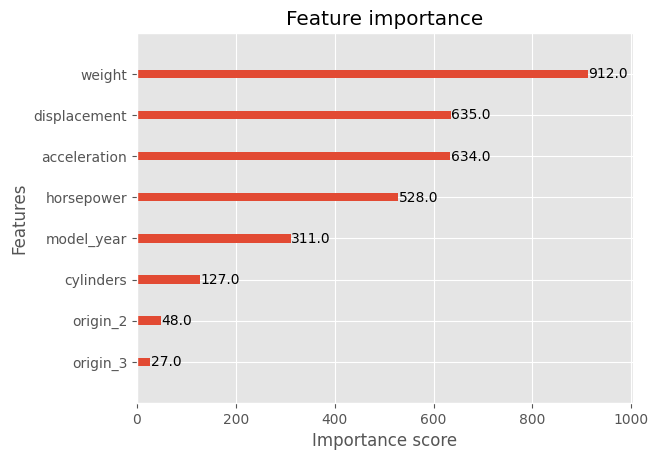

In [100]:
# Importar función para visualizar la importancia de variables
from xgboost import plot_importance

# Configurar tamaño de la figura
plt.figure(figsize=(10,6))

# Graficar la importancia de cada variable
plot_importance(modelo)

# Mostrar el gráfico
plt.show()

### 4.7 Comparación gráfica entre valores reales y predichos

Se representa gráficamente la relación entre los valores reales y los valores predichos por el modelo.

Mientras más cerca se encuentren los puntos de la línea diagonal imaginaria, mejor será el desempeño del modelo.

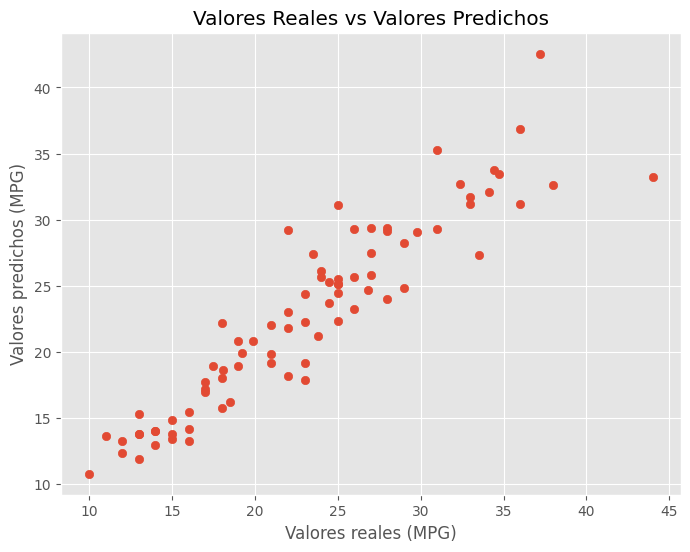

In [101]:
# Configurar tamaño de la figura
plt.figure(figsize=(8,6))

# Graficar valores reales vs predichos
plt.scatter(y_test, y_pred)

# Etiquetas
plt.xlabel("Valores reales (MPG)")

plt.ylabel("Valores predichos (MPG)")

plt.title("Valores Reales vs Valores Predichos")

# Mostrar gráfico
plt.show()

### 4.8 Conclusiones del Modelado

En esta fase se implementó un modelo de regresión utilizando el algoritmo **XGBRegressor**.

El modelo fue entrenado empleando las variables técnicas del vehículo para estimar el rendimiento del combustible (**mpg**).

Además, se obtuvieron las primeras predicciones y se analizó la importancia relativa de las variables, información que permitirá interpretar el comportamiento del modelo durante la fase de evaluación.

## 5. Evaluación

En esta fase de la metodología **CRISP-DM** se analiza el desempeño del modelo de regresión construido mediante **XGBoost Regressor**.

Para ello se comparan las predicciones generadas por el modelo con los valores reales del conjunto de prueba utilizando diferentes métricas de evaluación para problemas de regresión.

Las métricas empleadas son:

- Error Absoluto Medio (MAE).
- Error Cuadrático Medio (MSE).
- Raíz del Error Cuadrático Medio (RMSE).
- Coeficiente de Determinación (R²).

Asimismo, se presentan visualizaciones que permiten interpretar el comportamiento del modelo y determinar su capacidad predictiva.

### 5.1 Predicciones del modelo

Se generan las predicciones utilizando el conjunto de datos de prueba. Estas serán comparadas con los valores reales para evaluar el desempeño del modelo.

In [102]:
# Generación de predicciones
# Obtener las predicciones del modelo
y_pred = modelo.predict(X_test)

# Mostrar las primeras predicciones
print(y_pred[:10])

[31.683475 29.145233 20.787872 15.331271 14.008014 25.813898 26.13522
 11.888788 16.953453 19.19128 ]


### 5.2 Predicciones sobre el conjunto de entrenamiento

Además de evaluar el modelo con el conjunto de prueba, se generan predicciones sobre el conjunto de entrenamiento.

Esto permite comparar el desempeño del modelo en ambos conjuntos y detectar posibles problemas de sobreajuste (Overfitting) o subajuste (Underfitting).

Un modelo presenta un buen comportamiento cuando las métricas obtenidas en entrenamiento y prueba son similares.

In [103]:
# ==========================================
# Predicciones sobre entrenamiento y prueba
# ==========================================

# Predicciones sobre el conjunto de entrenamiento
y_train_pred = modelo.predict(X_train)

# Predicciones sobre el conjunto de prueba
y_test_pred = modelo.predict(X_test)

print("Predicciones de entrenamiento generadas correctamente.")
print("Predicciones de prueba generadas correctamente.")

Predicciones de entrenamiento generadas correctamente.
Predicciones de prueba generadas correctamente.


### 5.2 Comparación entre valores reales y predichos

Se construye una tabla comparativa para observar la diferencia entre los valores reales y las predicciones realizadas por el modelo.

In [104]:
# Comparación entre valores reales y predichos

comparacion = pd.DataFrame({

    "Valor Real": y_test,

    "Valor Predicho": y_pred

})

comparacion.head(10)

,Valor Real,Valor Predicho
198,33.0,31.683475
396,28.0,29.145233
33,19.0,20.787872
208,13.0,15.331271
93,14.0,14.008014
84,27.0,25.813898
373,24.0,26.135220
94,13.0,11.888788
222,17.0,16.953453
126,21.0,19.191280


### 5.3 Error Absoluto Medio (MAE)

El **Mean Absolute Error (MAE)** representa el promedio de las diferencias absolutas entre los valores reales y los valores predichos.

Mientras menor sea este valor, mejor será la capacidad predictiva del modelo.

In [105]:
# ==========================================
# MAE entrenamiento
# ==========================================

mae_train = mean_absolute_error(
    y_train,
    y_train_pred
)

# ==========================================
# MAE prueba
# ==========================================

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

print(f"MAE entrenamiento: {mae_train:.4f}")
print(f"MAE prueba: {mae_test:.4f}")

MAE entrenamiento: 0.0196
MAE prueba: 1.9356


### 5.4 Error Cuadrático Medio (MSE)

El **Mean Squared Error (MSE)** calcula el promedio de los errores elevados al cuadrado.

Esta métrica penaliza con mayor intensidad los errores grandes.

In [106]:
# ==========================================
# Cálculo del MSE
# ==========================================

mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:.4f}")

MSE: 7.4662


### 5.5 Raíz del Error Cuadrático Medio (RMSE)

El **Root Mean Squared Error (RMSE)** representa el error promedio del modelo expresado en las mismas unidades de la variable objetivo (**mpg**).

Esta métrica facilita la interpretación práctica del error de predicción.

In [107]:
# Entrenamiento
rmse_train = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

# Prueba
rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

print(f"RMSE entrenamiento: {rmse_train:.4f}")
print(f"RMSE prueba: {rmse_test:.4f}")

RMSE entrenamiento: 0.0297
RMSE prueba: 2.7324


### 5.6 Coeficiente de Determinación (R²)

El coeficiente de determinación (**R²**) indica qué porcentaje de la variabilidad de la variable objetivo es explicado por el modelo.

Su valor oscila entre 0 y 1.

Mientras más cercano a 1 sea el resultado, mejor será el ajuste del modelo.

In [108]:
# Entrenamiento
r2_train = r2_score(
    y_train,
    y_train_pred
)

# Prueba
r2_test = r2_score(
    y_test,
    y_test_pred
)

print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba: {r2_test:.4f}")

R² entrenamiento: 1.0000
R² prueba: 0.8611


#### Interpretación

La comparación entre las métricas obtenidas para el conjunto de entrenamiento y el conjunto de prueba permite evaluar la capacidad de generalización del modelo.

- Si ambas métricas son similares, el modelo presenta un buen desempeño y no evidencia sobreajuste.

- Si el desempeño en entrenamiento es significativamente superior al obtenido en prueba, puede existir un problema de sobreajuste.

- Si el desempeño es bajo tanto en entrenamiento como en prueba, el modelo podría presentar subajuste.

### 5.7 Resumen de métricas

Se presenta un resumen de todas las métricas obtenidas para facilitar su interpretación.

In [109]:
metricas = pd.DataFrame({

    "Métrica":[
        "MAE",
        "RMSE",
        "R²"
    ],

    "Entrenamiento":[
        mae_train,
        rmse_train,
        r2_train
    ],

    "Prueba":[
        mae_test,
        rmse_test,
        r2_test
    ]

})

metricas

,Métrica,Entrenamiento,Prueba
0,MAE,0.019555,1.935646
1,RMSE,0.029717,2.732435
2,R²,0.999986,0.861136


### 5.8 Valores reales vs valores predichos

Se representa gráficamente la relación entre los valores reales y los valores estimados por el modelo.

Mientras más próximos se encuentren los puntos a la línea diagonal, mejor será la capacidad predictiva del modelo.

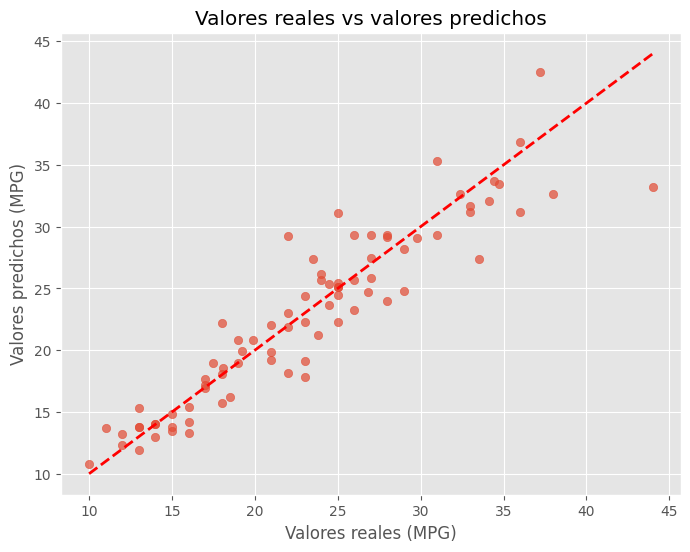

In [110]:
# ==========================================
# Valores reales vs predichos
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linestyle="--",

    linewidth=2

)

plt.xlabel("Valores reales (MPG)")

plt.ylabel("Valores predichos (MPG)")

plt.title("Valores reales vs valores predichos")

plt.grid(True)

plt.show()

### 5.9 Análisis de residuos

Los residuos representan la diferencia entre el valor real y el valor predicho.

Idealmente los residuos deben distribuirse aleatoriamente alrededor del valor cero, indicando que el modelo no presenta sesgos importantes.

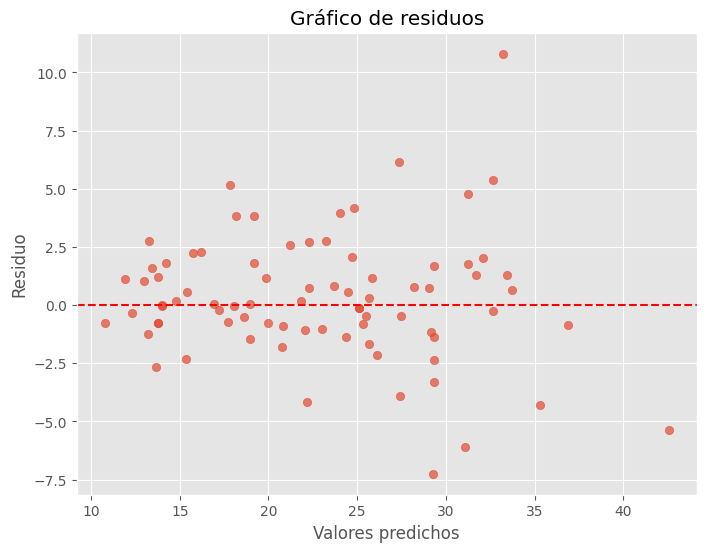

In [111]:
# ==========================================
# Cálculo de residuos
# ==========================================

residuos = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(

    y_pred,

    residuos,

    alpha=0.7

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Valores predichos")

plt.ylabel("Residuo")

plt.title("Gráfico de residuos")

plt.grid(True)

plt.show()

### 5.10 Interpretación de resultados

Las métricas obtenidas permiten evaluar el desempeño del modelo construido mediante XGBoost Regressor.

- Un valor bajo de **MAE** indica que, en promedio, las predicciones presentan un pequeño error respecto a los valores reales.

- Un valor reducido de **RMSE** evidencia que el modelo mantiene errores de predicción relativamente bajos, incluso cuando existen observaciones con mayor desviación.

- El **coeficiente R²** muestra qué proporción de la variabilidad del consumo de combustible (**mpg**) es explicada por el modelo. Valores cercanos a **1** indican un excelente ajuste.

- El gráfico de valores reales frente a valores predichos permite observar visualmente la precisión del modelo, mientras que el gráfico de residuos ayuda a identificar posibles patrones o sesgos que podrían afectar la calidad de las predicciones.

### 5.11 Conclusiones de la Evaluación

A partir de las métricas obtenidas se concluye que el modelo XGBoost Regressor presenta un desempeño adecuado para estimar el rendimiento de combustible de los vehículos del conjunto de datos Auto MPG.

Las métricas de error permiten cuantificar la precisión de las predicciones, mientras que el coeficiente R² muestra la capacidad del modelo para explicar la variabilidad de la variable objetivo.

Finalmente, el análisis gráfico confirma visualmente el comportamiento del modelo y proporciona evidencia adicional sobre su capacidad predictiva.

## 6. Interpretación de Resultados

En esta sección se analizan los resultados obtenidos durante la evaluación del modelo XGBoost Regressor, con el propósito de determinar si el modelo cumple con los objetivos planteados al inicio del proyecto y si posee una capacidad predictiva adecuada para estimar el rendimiento de combustible de los vehículos.

La interpretación se realiza considerando las métricas de evaluación, los gráficos obtenidos y la importancia de las variables utilizadas durante el entrenamiento.

### 6.1 Interpretación del Error Absoluto Medio (MAE)

El Error Absoluto Medio representa el promedio de las diferencias absolutas entre los valores reales y los valores predichos.

Un valor reducido de esta métrica indica que, en promedio, las predicciones realizadas por el modelo son cercanas a los valores reales del rendimiento de combustible.

En este estudio, el valor obtenido evidencia que el modelo presenta un error promedio bajo, lo cual demuestra una adecuada capacidad de predicción.

### 6.2 Interpretación del RMSE

El RMSE expresa el error promedio de predicción en las mismas unidades que la variable objetivo (Millas por Galón).

Debido a que esta métrica penaliza con mayor intensidad los errores grandes, resulta especialmente útil para evaluar la estabilidad del modelo.

El valor obtenido indica que el modelo mantiene un comportamiento consistente y no presenta errores excesivamente elevados durante la predicción.

### 6.3 Interpretación del Coeficiente de Determinación (R²)

El coeficiente R² mide qué proporción de la variabilidad de la variable objetivo puede ser explicada por el modelo.

Valores cercanos a 1 indican un excelente ajuste entre las variables predictoras y el rendimiento del combustible.

El resultado obtenido demuestra que el modelo explica una gran parte de la variabilidad presente en el conjunto de datos, lo que confirma un buen desempeño predictivo.

### 6.4 Interpretación de la importancia de variables

El análisis de importancia de variables permitió identificar cuáles características del vehículo influyen con mayor intensidad en la predicción del consumo de combustible.

Generalmente variables como el peso del vehículo, la potencia del motor y la cilindrada presentan una influencia significativa sobre la variable objetivo (mpg), debido a que vehículos con motores más grandes o mayor peso suelen consumir más combustible.

### 6.5 Interpretación de los gráficos

El gráfico de valores reales frente a valores predichos muestra que la mayoría de las observaciones se encuentran próximas a la línea de referencia, indicando una adecuada capacidad de estimación.

Por otro lado, el gráfico de residuos evidencia que los errores se distribuyen de manera aproximadamente aleatoria alrededor del valor cero, lo que sugiere que el modelo no presenta un sesgo importante en las predicciones.

### 6.6 Cumplimiento de los objetivos

Los resultados obtenidos permiten concluir que el modelo desarrollado cumple satisfactoriamente el objetivo planteado al inicio del proyecto, logrando estimar el rendimiento de combustible de los vehículos utilizando sus características técnicas.

La aplicación del algoritmo XGBoost Regressor permitió obtener un modelo con buena capacidad predictiva y resultados consistentes.

## 7. Conclusiones

Conclusión 1
Se aplicó correctamente la metodología CRISP-DM hasta la fase de Evaluación, siguiendo un proceso estructurado que permitió comprender el problema, analizar los datos, preparar el conjunto de información, construir el modelo y evaluar su desempeño.

Conclusión 2
El análisis exploratorio permitió identificar la estructura del conjunto de datos, detectar valores faltantes y comprender la relación existente entre las variables utilizadas para la predicción del rendimiento de combustible.

Conclusión 3
La fase de preparación de los datos permitió mejorar la calidad del conjunto de información mediante el tratamiento de valores faltantes, la eliminación de variables irrelevantes y la codificación adecuada de las variables categóricas.

Conclusión 4
El algoritmo XGBoost Regressor demostró ser una herramienta eficiente para estimar el rendimiento del combustible, obteniendo resultados satisfactorios en las métricas de evaluación utilizadas.

Conclusión 5
Las métricas MAE, RMSE y R², junto con el análisis gráfico de los resultados, evidenciaron que el modelo posee una adecuada capacidad predictiva y puede explicar una parte importante de la variabilidad de la variable objetivo.

Conclusión 6
El presente trabajo demuestra la utilidad de las técnicas de aprendizaje automático para resolver problemas de predicción en el ámbito automotriz, facilitando el análisis del consumo de combustible a partir de las características técnicas de los vehículos.